## 02c Experiment 1 - Attributes Task: General Analyses

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np

In [ ]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df.head()

In [3]:
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

In [ ]:
# Total Attributes generated per model

model_items = attributes_df.explode('output_list_processed_nonoise')

total_item_counts = model_items.groupby('model').size().reset_index(name='total_attributes')

print(total_item_counts)

                         model  total_attributes
0  Meta-Llama-3.1-70B-Instruct              9295
1   Meta-Llama-3.1-8B-Instruct              8256
2         Qwen2.5-14B-Instruct              6079
3         Qwen2.5-32B-Instruct              8084
4         Qwen2.5-72B-Instruct              8141
5          Qwen2.5-7B-Instruct              4265
6                deepseek-chat             17025
7                 gemini-3-pro             17401
8                      gpt-5.2             29787


In [ ]:
# Unique attributes count per model per category

model_items = attributes_df.explode('output_list_processed_nonoise')

unique_item_counts = (
    model_items.groupby(['model', 'category'])['output_list_processed_nonoise']
    .nunique()
    .reset_index(name='unique_attribute_count')
)

print(unique_item_counts)

                          model   category  unique_attribute_count
0   Meta-Llama-3.1-70B-Instruct   Clothing                     264
1   Meta-Llama-3.1-70B-Instruct      Fruit                     143
2   Meta-Llama-3.1-70B-Instruct  Furniture                     189
3   Meta-Llama-3.1-70B-Instruct  Vegetable                     155
4   Meta-Llama-3.1-70B-Instruct    Vehicle                     222
5   Meta-Llama-3.1-70B-Instruct     Weapon                     210
6    Meta-Llama-3.1-8B-Instruct   Clothing                     229
7    Meta-Llama-3.1-8B-Instruct      Fruit                     123
8    Meta-Llama-3.1-8B-Instruct  Furniture                     207
9    Meta-Llama-3.1-8B-Instruct  Vegetable                     177
10   Meta-Llama-3.1-8B-Instruct    Vehicle                     210
11   Meta-Llama-3.1-8B-Instruct     Weapon                     227
12         Qwen2.5-14B-Instruct   Clothing                     177
13         Qwen2.5-14B-Instruct      Fruit                    

In [ ]:
# Frequency

def count_unique_items_per_model(df):
    exploded_df = df.explode('output_list_processed_nonoise')
    unique_counts = exploded_df.groupby(['model', 'category'])['output_list_processed_nonoise'].nunique().reset_index()
    unique_counts.columns = ['model', 'category', 'unique_item_count']
    return unique_counts

unique_item_counts_per_model = count_unique_items_per_model(attributes_df)
unique_item_counts_per_model

pivot_data = unique_item_counts_per_model.pivot(index='model', columns='category', values='unique_item_count')

plt.figure(figsize=(12, 10))  

mask = pivot_data.isnull()

sns.heatmap(pivot_data, annot=True, fmt='d', cmap='coolwarm', mask=mask, cbar_kws={'label': 'Unique Attributes Count'})

plt.xlabel('Category', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.yticks(rotation=45, ha='right')

# Save the figure as a PDF file
#plt.savefig('02_AttributesFigures/attributesfreq_heatmap.pdf', format='pdf', bbox_inches='tight')  # Use appropriate filename


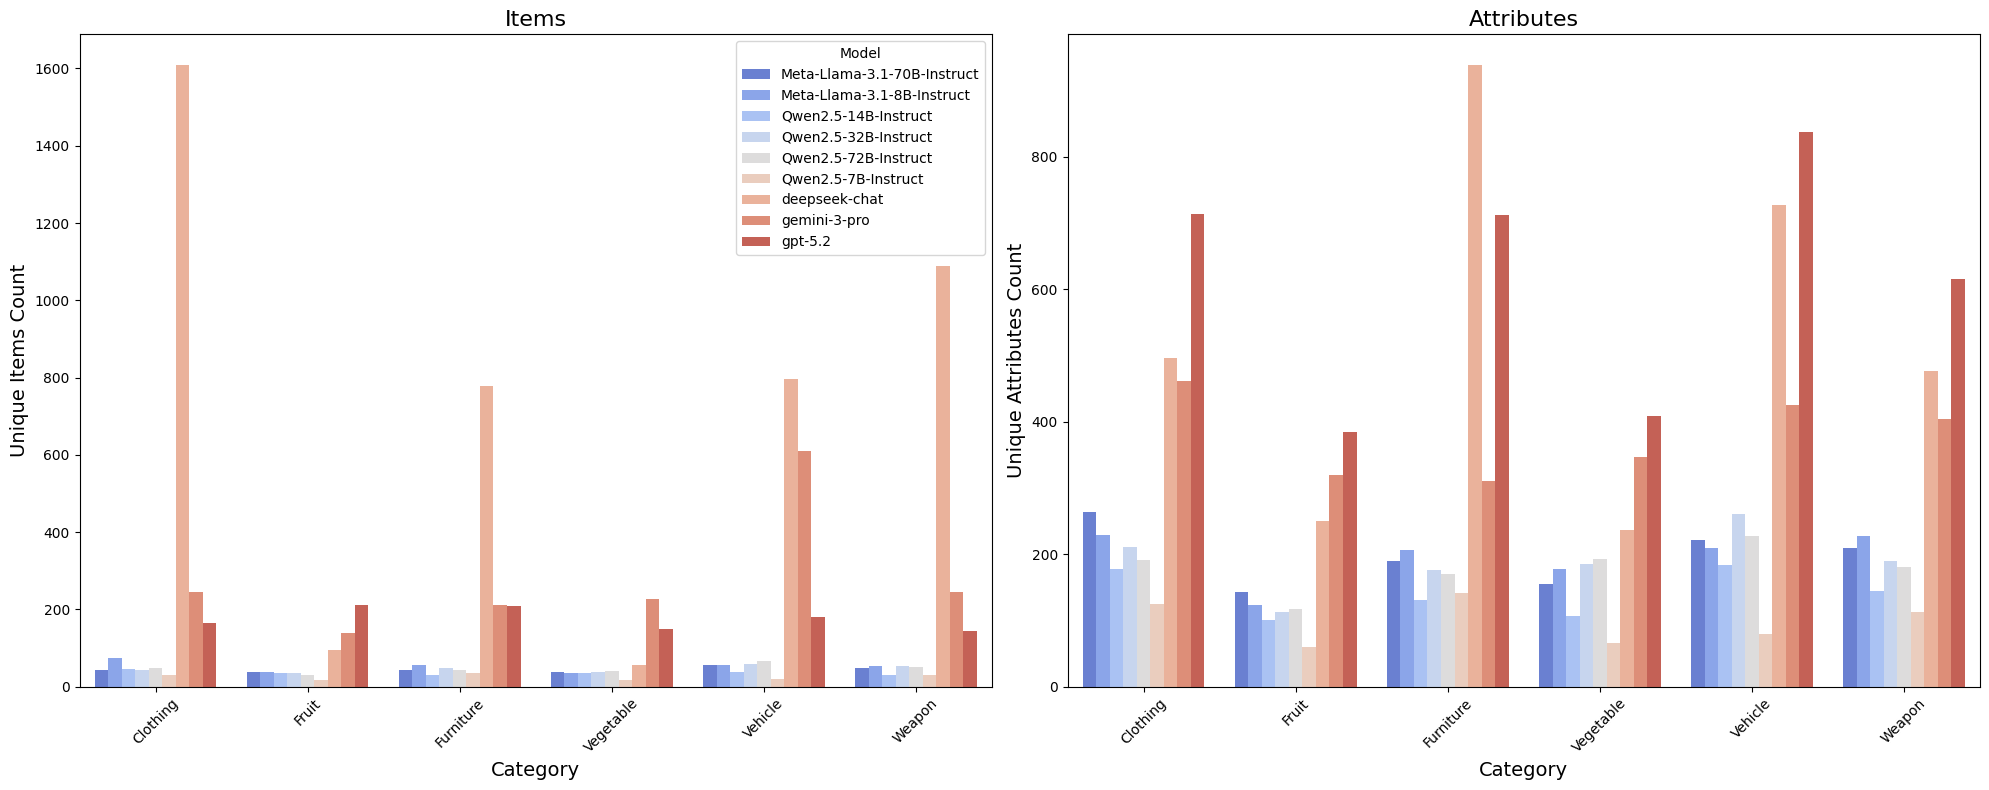

In [ ]:
# Checking number of items and attributes outputted by each model --> TO CHECK IF THE MOST POPULOUS CATEGORIES AND MOST PRODUCTIVE MODELS SHOW
# STRONGER PROTOTYPICALITY EFFECTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_df  = pd.read_csv('01_catmemexp_itemstask_allmodels_processed_FINAL.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

# Function to count unique items per model and category
def count_unique_items_per_model(df):
    exploded_df = df.explode('output_list_processed_nonoise')
    unique_counts = exploded_df.groupby(['model', 'category'])['output_list_processed_nonoise'].nunique().reset_index()
    unique_counts.columns = ['model', 'category', 'unique_item_count']
    return unique_counts

# Get unique item counts for each model from both dataframes
unique_item_counts_per_model_1 = count_unique_items_per_model(items_df)
unique_item_counts_per_model_2 = count_unique_items_per_model(attributes_df)

# Set up the subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.barplot(data=unique_item_counts_per_model_1, x='category', y='unique_item_count', hue='model', ax=axes[0], palette='coolwarm')
axes[0].set_title('Items', fontsize=16)
axes[0].set_xlabel('Category', fontsize=14)
axes[0].set_ylabel('Unique Items Count', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Model')

sns.barplot(data=unique_item_counts_per_model_2, x='category', y='unique_item_count', hue='model', ax=axes[1], palette='coolwarm', legend = False)
axes[1].set_title('Attributes', fontsize=16)
axes[1].set_xlabel('Category', fontsize=14)
axes[1].set_ylabel('Unique Attributes Count', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout() 
plt.show()


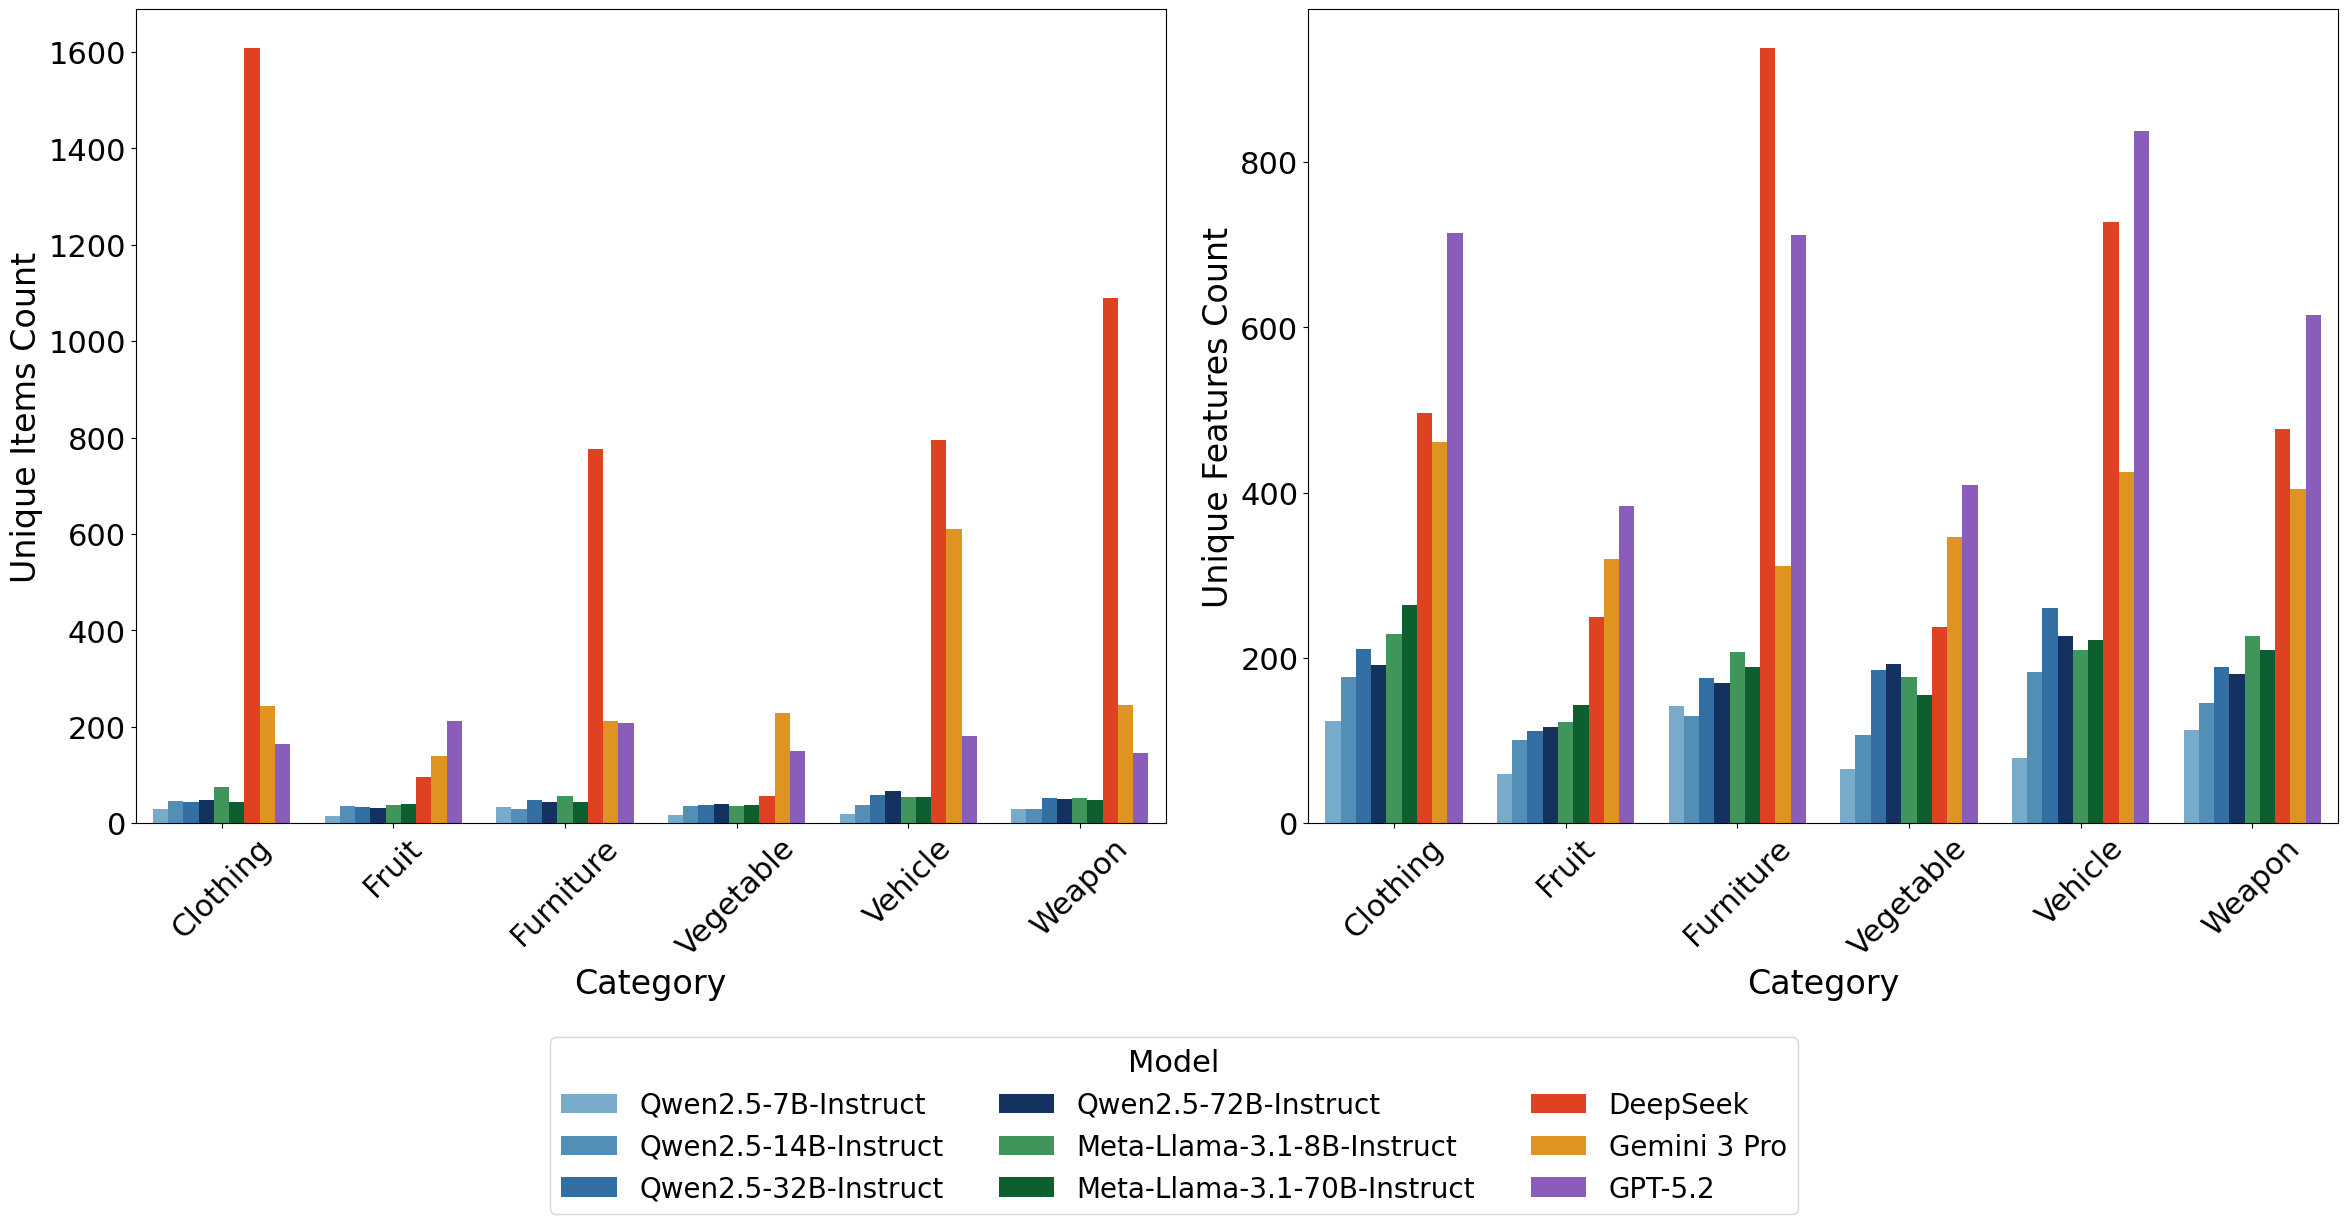

In [ ]:
items_df  = pd.read_csv(
    '01_catmemexp_itemstask_allmodels_processed_FINAL.csv',
    dtype=str,
    quoting=csv.QUOTE_ALL,
    encoding="utf-8"
)

items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'GPT-5.2': '#8a4dca'
}

model_name_mapping = {
    'Qwen2.5-7B-Instruct': 'Qwen2.5-7B-Instruct',
    'Qwen2.5-14B-Instruct': 'Qwen2.5-14B-Instruct',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B-Instruct',
    'Qwen2.5-72B-Instruct': 'Qwen2.5-72B-Instruct',
    'Meta-Llama-3.1-8B-Instruct': 'Meta-Llama-3.1-8B-Instruct',
    'Meta-Llama-3.1-70B-Instruct': 'Meta-Llama-3.1-70B-Instruct',
    'deepseek-chat': 'DeepSeek',
    'DeepSeek': 'DeepSeek',
    'gemini-3-pro': 'Gemini 3 Pro',
    'Gemini 3 Pro': 'Gemini 3 Pro',
    'gpt-5.2': 'GPT-5.2',
    'GPT-5.2': 'GPT-5.2'
}

items_df['model'] = items_df['model'].replace(model_name_mapping)

attributes_df['model'] = attributes_df['model'].replace(model_name_mapping)

def count_unique_items_per_model(df):
    exploded_df = df.explode('output_list_processed_nonoise')
    unique_counts = (
        exploded_df
        .groupby(['model', 'category'])['output_list_processed_nonoise']
        .nunique()
        .reset_index()
    )
    unique_counts.columns = ['model', 'category', 'unique_item_count']
    return unique_counts

counts_items = count_unique_items_per_model(items_df)
counts_attributes = count_unique_items_per_model(attributes_df)

model_order = [m for m in model_palette if m in counts_items['model'].unique()]

plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 20,
    'legend.title_fontsize': 22
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))  

sns.barplot(
    data=counts_items,
    x='category',
    y='unique_item_count',
    hue='model',
    hue_order=model_order,
    palette=model_palette,
    ax=axes[0]
)

axes[0].set_xlabel('Category')
axes[0].set_ylabel('Unique Items Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=counts_attributes,
    x='category',
    y='unique_item_count',
    hue='model',
    hue_order=model_order,
    palette=model_palette,
    ax=axes[1],
    legend=False
)

axes[1].set_xlabel('Category')
axes[1].set_ylabel('Unique Features Count')
axes[1].tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Model',
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05)  
)

axes[0].legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  

plt.savefig('00_PromptFigures/appendix_figure_model_tot_items_percat.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Frequency

def count_unique_items_per_model(df):
    exploded_df = df.explode('output_list_processed_nonoise')
    unique_counts = exploded_df.groupby(['model', 'category'])['output_list_processed_nonoise'].nunique().reset_index()
    unique_counts.columns = ['model', 'category', 'unique_item_count']
    return unique_counts

unique_item_counts_per_model = count_unique_items_per_model(attributes_df)
unique_item_counts_per_model

pivot_data = unique_item_counts_per_model.pivot(index='model', columns='category', values='unique_item_count')

log_pivot_data = np.log1p(pivot_data)

plt.figure(figsize=(12, 10))

mask = log_pivot_data.isnull()

sns.heatmap(log_pivot_data, annot=pivot_data, fmt='d', cmap='coolwarm', mask=mask, cbar_kws={'label': 'Unique Attributes Count (log)'})

plt.xlabel('Category', fontsize=14)
plt.ylabel('Model', fontsize=14)

plt.yticks(rotation=45, ha='right')

plt.savefig('02_AttributesFigures/attributesfreq_heatmap_log.pdf', format='pdf', bbox_inches='tight')  

plt.show()


In [10]:
# Collecting Attribute Frequencies per model
model_items = attributes_df.explode('output_list_processed_nonoise')
item_counts = model_items.groupby(['model', 'output_list_processed_nonoise']).size().reset_index(name='frequency')
item_counts

,model,output_list_processed_nonoise,frequency
0,DeepSeek,12-hour,3
1,DeepSeek,24-hour,3
2,DeepSeek,abs,2
3,DeepSeek,absolute,5
4,DeepSeek,absorbent,24
...,...,...,...
11516,Qwen2.5-7B-Instruct,yellow,35
11517,Qwen2.5-7B-Instruct,zipped,7
11518,Qwen2.5-7B-Instruct,zippered,2
11519,Qwen2.5-7B-Instruct,手工的,2


In [ ]:
# Explode attributes
model_items = attributes_df.explode('output_list_processed_nonoise')

item_counts = (
    model_items
    .groupby(['model', 'category', 'output_list_processed_nonoise'])
    .size()
    .reset_index(name='frequency')
)

top5_features = (
    item_counts
    .sort_values(['model', 'category', 'frequency'], ascending=[True, True, False])
    .groupby(['model', 'category'])
    .head(5)
)

top5_summary = (
    top5_features
    .groupby(['model', 'category'])
    .apply(lambda x: list(zip(x['output_list_processed_nonoise'], x['frequency'])))
    .reset_index(name='top_5_features')
)

top5_features['feature_with_freq'] = (
    top5_features['output_list_processed_nonoise']
    + " (" + top5_features['frequency'].astype(str) + ")"
)

top5_features['rank'] = (
    top5_features
    .groupby(['model', 'category'])['frequency']
    .rank(method='first', ascending=False)
    .astype(int)
)

top5_table = top5_features.pivot(
    index=['model', 'category'],
    columns='rank',
    values='feature_with_freq'
).reset_index()

top5_table.columns = ['model', 'category', 'Top 1', 'Top 2', 'Top 3', 'Top 4', 'Top 5']

top5_table

C:\Users\AS\AppData\Local\Temp\ipykernel_12804\1460796902.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: list(zip(x['output_list_processed_nonoise'], x['frequency'])))


,model,category,Top 1,Top 2,Top 3,Top 4,Top 5
0,DeepSeek,Clothing,durable (51),lightweight (38),casual (37),cotton (33),breathable (30)
1,DeepSeek,Fruit,edible (70),sweet (66),fleshy (60),nutritious (57),juicy (55)
2,DeepSeek,Furniture,modern (65),decorative (62),wooden (61),antique (57),rectangular (55)
3,DeepSeek,Vegetable,edible (85),fibrous (64),nutritious (59),vegetable (44),green (40)
4,DeepSeek,Vehicle,durable (46),utilitarian (46),wooden (30),large (27),lightweight (27)
5,DeepSeek,Weapon,handheld (39),heavy (38),metallic (34),portable (27),functional (24)
6,GPT-5.2,Clothing,lightweight (80),durable (74),breathable (71),comfortable (66),patterned (56)
7,GPT-5.2,Fruit,aromatic (87),fragrant (76),fresh (76),juicy (76),edible (72)
8,GPT-5.2,Furniture,sturdy (88),durable (81),compact (76),modern (74),traditional (74)
9,GPT-5.2,Vegetable,edible (74),aromatic (72),fibrous (69),earthy (68),tender (63)


In [ ]:
# Shuffle first to randomize ties
item_counts_shuffled = item_counts.sample(frac=1, random_state=42)

bottom5_features = (
    item_counts_shuffled
    .sort_values(['model', 'category', 'frequency'], ascending=[True, True, True])
    .groupby(['model', 'category'])
    .head(5)
)

bottom5_features['feature_with_freq'] = (
    bottom5_features['output_list_processed_nonoise']
    + " (" + bottom5_features['frequency'].astype(str) + ")"
)

bottom5_features['rank'] = (
    bottom5_features
    .groupby(['model', 'category'])
    .cumcount() + 1
)

bottom5_table = bottom5_features.pivot(
    index=['model', 'category'],
    columns='rank',
    values='feature_with_freq'
).reset_index()

bottom5_table.columns = ['model', 'category', 'Bottom 1', 'Bottom 2', 'Bottom 3', 'Bottom 4', 'Bottom 5']

bottom5_table

In [ ]:
sub_df = attributes_df[attributes_df['model'] == 'gpt-5.2']

grouped = sub_df.groupby('category')['item'].unique()

unique_items_dict = {category: list(items) for category, items in grouped.items()}

unique_items_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in unique_items_dict.items()]))

#unique_items_df.to_csv('example_table_2.csv', index=False)

print(unique_items_df)


Empty DataFrame
Columns: []
Index: []


In [ ]:
# Attribute Frequency Histograms

unique_models = attributes_df['model'].unique()

for model in unique_models:

    unique_categories = attributes_df['category'].unique()
    
    ncols = 3  
    nrows = 6  
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 24), sharey=True)
   
    for category_index, category in enumerate(unique_categories):
        for frequency_type_index, frequency_type in enumerate(['most_frequent', 'average_frequency', 'least_frequent']):

            filtered_df = attributes_df[
                (attributes_df['frequency'] == frequency_type) &
                (attributes_df['category'] == category) &
                (attributes_df['model'] == model)
            ]

            unique_items = filtered_df['item'].unique()
            all_counts = []

            for item in unique_items:
     
                attributes = []
                item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values
                
                for row in item_attributes:
                    attributes.extend(row)

           
                attribute_counts = Counter(attributes)
                
             
                sorted_attributes = sorted(attribute_counts.items(), key=lambda pair: pair[1], reverse=True)

                frequency_index_mapping = {attribute: index for index, (attribute, _) in enumerate(sorted_attributes)}
                
               
                renaming_map = {attribute: f'attr_{index}' for attribute, index in frequency_index_mapping.items()}
             
                counts = [count for _, count in sorted_attributes]
                all_counts.append((renaming_map, counts))

       
            cmap = plt.get_cmap('viridis', len(unique_items))

         
            for index, (renaming_map, counts) in enumerate(all_counts):
                keys = [renaming_map[key] for key in renaming_map.keys()]

                axs[category_index, frequency_type_index].bar(keys, counts, color=cmap(index), 
                                                              alpha=0.7, label=f'{unique_items[index]}', align='center')

            axs[category_index, frequency_type_index].set_title(f'{category} - {frequency_type}')
            axs[category_index, frequency_type_index].set_ylabel('Frequency')
            axs[category_index, frequency_type_index].set_xlabel('Attributes')
            
          
            axs[category_index, frequency_type_index].set_xticks([])
            axs[category_index, frequency_type_index].legend()


    for i in range(len(unique_categories), nrows):
        for j in range(ncols):
            fig.delaxes(axs[i, j])

    fig.suptitle(f'{model}', fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
    plt.savefig(f'02_AttributesFigures/{model}_attributes_freqdist_nonoise.pdf', format='pdf')
    plt.show()


In [ ]:
unique_models = attributes_df['model'].unique()

for model in unique_models:

    unique_categories = attributes_df['category'].unique()
    
    ncols = 3  
    nrows = len(unique_categories)  

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 24), sharey=True)

    for category_index, category in enumerate(unique_categories):
        for frequency_type_index, frequency_type in enumerate(['most_frequent', 'average_frequency', 'least_frequent']):
            
            filtered_df = attributes_df[
                (attributes_df['frequency'] == frequency_type) &
                (attributes_df['category'] == category) &
                (attributes_df['model'] == model)
            ]
            
            
            unique_items = filtered_df['item'].unique()
            all_counts = {}
            attribute_set = set()  
            
            for item in unique_items:
                item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values
                attributes = []
                
                for row in item_attributes:
                    attributes.extend(row)
                    
                attribute_counts = Counter(attributes)

                counts = {attr: count for attr, count in attribute_counts.items()}
                
                all_counts[item] = counts
                attribute_set.update(counts.keys())

            attribute_list = sorted(attribute_set)
            bottom_counts = np.zeros(len(attribute_list))  
    
            cmap = plt.get_cmap('viridis', len(unique_items))
  
            for index, item in enumerate(unique_items):
                counts = [all_counts[item].get(attr, 0) for attr in attribute_list]  
                
                axs[category_index, frequency_type_index].bar(attribute_list, counts,
                                                              color=cmap(index), 
                                                              alpha=0.7, 
                                                              label=f'{item}', 
                                                              align='center', 
                                                              bottom=bottom_counts)

                bottom_counts += counts

            axs[category_index, frequency_type_index].set_title(f'{category} - {frequency_type}')
            axs[category_index, frequency_type_index].set_ylabel('Frequency')
            axs[category_index, frequency_type_index].set_xlabel('Attributes')

            axs[category_index, frequency_type_index].set_xticks([])  
            axs[category_index, frequency_type_index].legend()

    fig.suptitle(f'Model: {model}', fontsize=20)

    # Adjust layout for clarity
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.savefig(f'02_AttributesFigures/{model}_attributes_freqdist_nonoise_stacked.pdf', format='pdf')
    plt.show()


### Order & Frequency

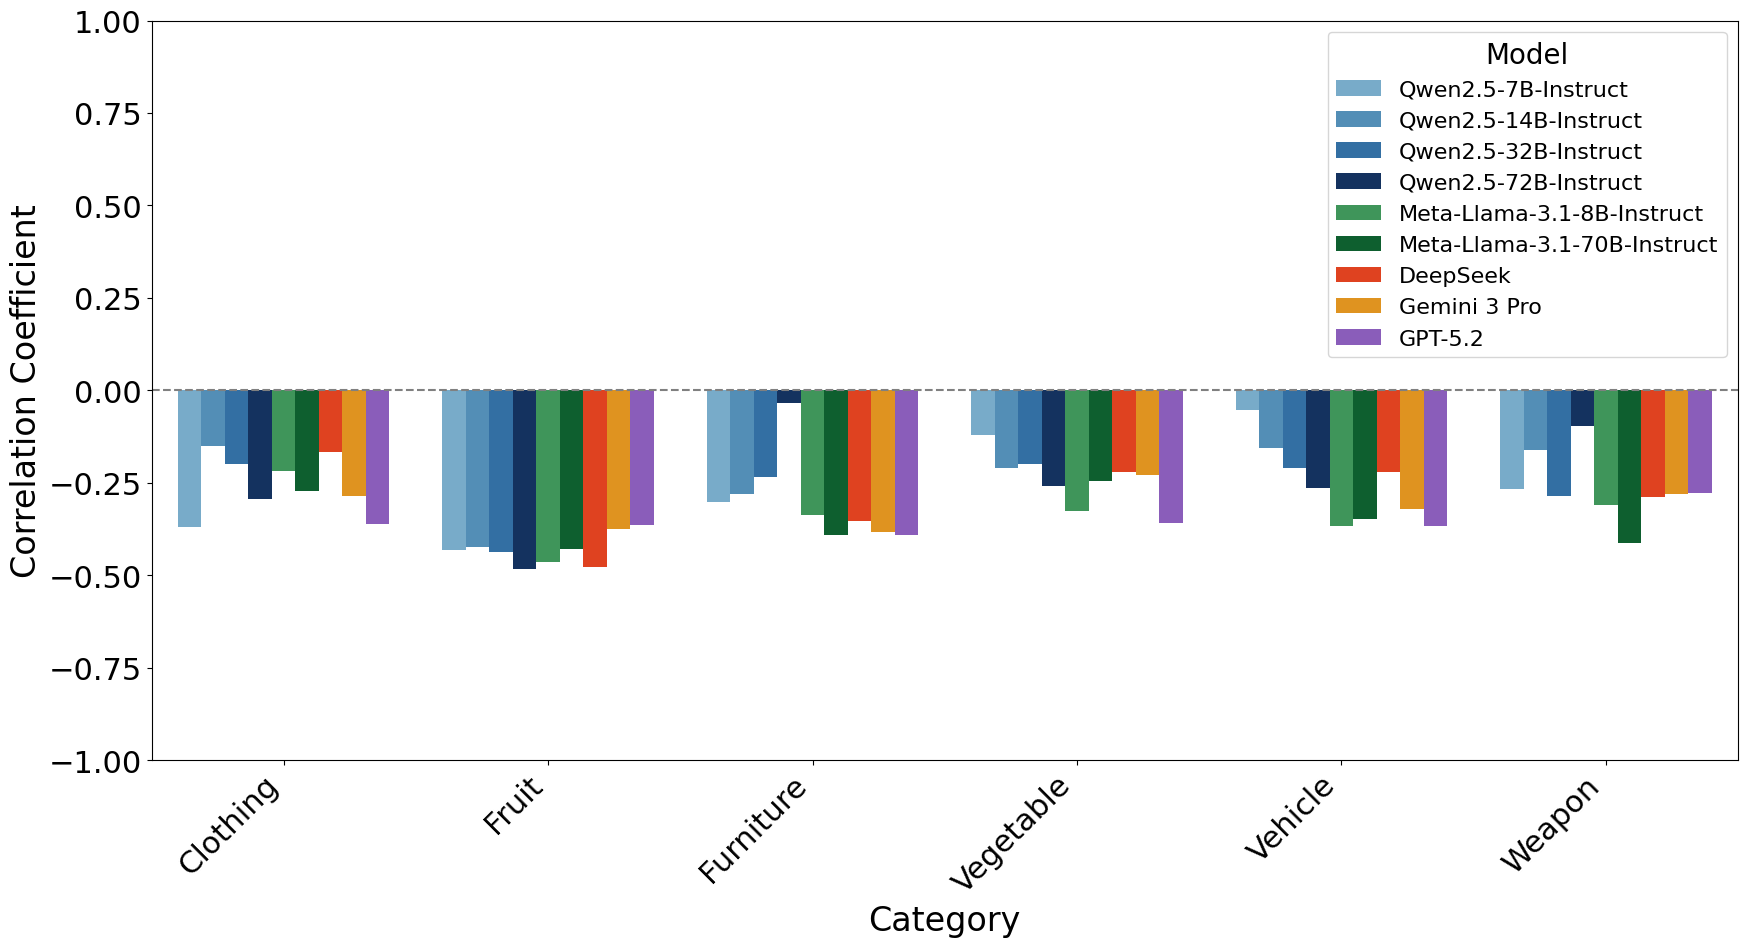

In [ ]:
model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'GPT-5.2': '#8a4dca'
}

model_name_mapping = {
    'Qwen2.5-7B-Instruct': 'Qwen2.5-7B-Instruct',
    'Qwen2.5-14B-Instruct': 'Qwen2.5-14B-Instruct',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B-Instruct',
    'Qwen2.5-72B-Instruct': 'Qwen2.5-72B-Instruct',
    'Meta-Llama-3.1-8B-Instruct': 'Meta-Llama-3.1-8B-Instruct',
    'Meta-Llama-3.1-70B-Instruct': 'Meta-Llama-3.1-70B-Instruct',
    'deepseek-chat': 'DeepSeek',
    'DeepSeek': 'DeepSeek',
    'gemini-3-pro': 'Gemini 3 Pro',
    'Gemini 3 Pro': 'Gemini 3 Pro',
    'gpt-5.2': 'GPT-5.2',
    'GPT-5.2': 'GPT-5.2'
}

def visualize_correlation_bar_plot(df):

    df = df.copy()
    df['model'] = df['model'].replace(model_name_mapping)

    analysis_data = []

    for (model, category), group in df.groupby(['model', 'category']):
        exploded_items = group['output_list_processed_nonoise'].explode()
        items_count = exploded_items.value_counts()

        for _, row in group.iterrows():
            for idx, output_item in enumerate(row['output_list_processed_nonoise'], start=1):
                analysis_data.append({
                    "model": model,
                    "category": category,
                    "item": row['item'],
                    "attribute": output_item,
                    "frequency": items_count.get(output_item, 0),
                    "order": idx
                })

    df_analysis = pd.DataFrame(analysis_data)

    avg_positions = (
        df_analysis.groupby('attribute', as_index=False)['order']
        .mean()
        .rename(columns={'order': 'average_order'})
    )

    df_analysis = df_analysis.merge(avg_positions, on='attribute')

    correlation_results = []

    for model in df_analysis['model'].unique():
        model_data = df_analysis[df_analysis['model'] == model]

        for category in model_data['category'].unique():
            category_data = model_data[model_data['category'] == category]

            for subcategory in category_data['item'].unique():
                sub_data = category_data[category_data['item'] == subcategory]

                corr = sub_data[['average_order', 'frequency']].corr().iloc[0, 1]

                correlation_results.append({
                    'model': model,
                    'category': category,
                    'correlation': corr
                })

    df_corr = pd.DataFrame(correlation_results)

    aggregated = (
        df_corr.groupby(['model', 'category'], as_index=False)['correlation']
        .mean()
    )

    model_order = [m for m in model_palette if m in aggregated['model'].unique()]
    aggregated = aggregated[aggregated['model'].isin(model_order)]

    plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 16,  
    'legend.title_fontsize': 20  
})

    plt.figure(figsize=(18, 10))

    sns.barplot(
        data=aggregated,
        x='category',
        y='correlation',
        hue='model',
        hue_order=model_order,
        palette=model_palette
    )

    plt.xlabel('Category')
    plt.ylabel('Correlation Coefficient')

    plt.axhline(0, color='gray', linestyle='--')

    plt.xticks(rotation=45, ha='right')
    plt.ylim(-1, 1)

    plt.legend(title='Model', loc='upper right')

    plt.tight_layout()
    plt.savefig('02_AttributesFigures/appendix_figure_order_frequency_features.pdf', format='pdf')
    plt.show()


# Call function
visualize_correlation_bar_plot(attributes_df)

In [ ]:
# Correlation for each item separately

def visualize_correlation_combined(df):
    analysis_data = []

    for (model, category), group in df.groupby(['model', 'category']):
        exploded_items = group['output_list_processed_nonoise'].explode()
        items_count = exploded_items.value_counts()

        for index, row in group.iterrows():
            for output_item in row['output_list_processed_nonoise']:
                item_index = row['output_list_processed_nonoise'].index(output_item) + 1  
                analysis_data.append({
                    "model": model,
                    "category": category,
                    "item": row['item'],
                    "attribute": output_item,
                    "frequency": items_count.get(output_item, 0),
                    "order": item_index
                })

    df_analysis = pd.DataFrame(analysis_data)

    average_positions = df_analysis.groupby('attribute')['order'].mean().reset_index()
    average_positions.rename(columns={'order': 'average_order'}, inplace=True)

    df_analysis = df_analysis.merge(average_positions, on='attribute')

    correlation_results = []
    unique_models = df['model'].unique()

    for model in unique_models:
        model_data = df_analysis[df_analysis['model'] == model]
        unique_categories = model_data['category'].unique()

        for category in unique_categories:
            category_data = model_data[model_data['category'] == category]
            unique_subcategories = category_data['item'].unique()

            for subcategory in unique_subcategories:
                subcategory_data = category_data[category_data['item'] == subcategory]

                correlation = subcategory_data[['average_order', 'frequency']].corr().iloc[0, 1]

                correlation_results.append({
                    'model': model,
                    'category': category,
                    'item': subcategory,
                    'correlation': correlation
                })

    df_correlations = pd.DataFrame(correlation_results)

    for model_index, model in enumerate(unique_models):
        model_df = df_correlations[df_correlations['model'] == model]

        if model_df.empty: 
            continue

        plt.figure(figsize=(16, 6)) 

        bar_width = 0.6

        sns.barplot(data=model_df, 
                     x='item', 
                     y='correlation', 
                     hue='category', 
                     palette='husl',
                     width=bar_width)  

        plt.axhline(0, color='gray', linestyle='--')  
        plt.ylim(-1, 1)  
        plt.title(f'{model}')
        plt.ylabel('Aggregate Correlation Coefficient')

        plt.xticks(rotation=45, ha='right', fontsize=10)  

        plt.legend(title='Model', loc='upper right')
        
        plt.tight_layout()
        plt.savefig(f'02_AttributesFigures/correlation_attributes_{model}.pdf', format='pdf')
        plt.show()

visualize_correlation_combined(attributes_df)
